In [4]:
!pip install pandas
!pip install matplotlib 
!pip install numpy
!pip install surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 93.8 MB/s eta 0:00:00ta 0:00:01


--- Starting Collaborative Filtering Model Benchmark ---
Evaluating User-KNN (Memory-Based)...
Evaluating Item-KNN (Memory-Based)...
Evaluating SVD (Matrix Factorization)...
Evaluating NMF (Non-Negative MF)...

--- Evaluation Matrix Saved as 'cf_model_comparison.png' ---
        Model Architecture  Mean RMSE  Mean MAE  Avg Fit Time (s)
   User-KNN (Memory-Based)   1.294105  1.060401          0.074276
   Item-KNN (Memory-Based)   1.290935  1.073976          0.024190
SVD (Matrix Factorization)   1.313953  1.088917          0.050961
     NMF (Non-Negative MF)   1.288822  1.083260          0.065440


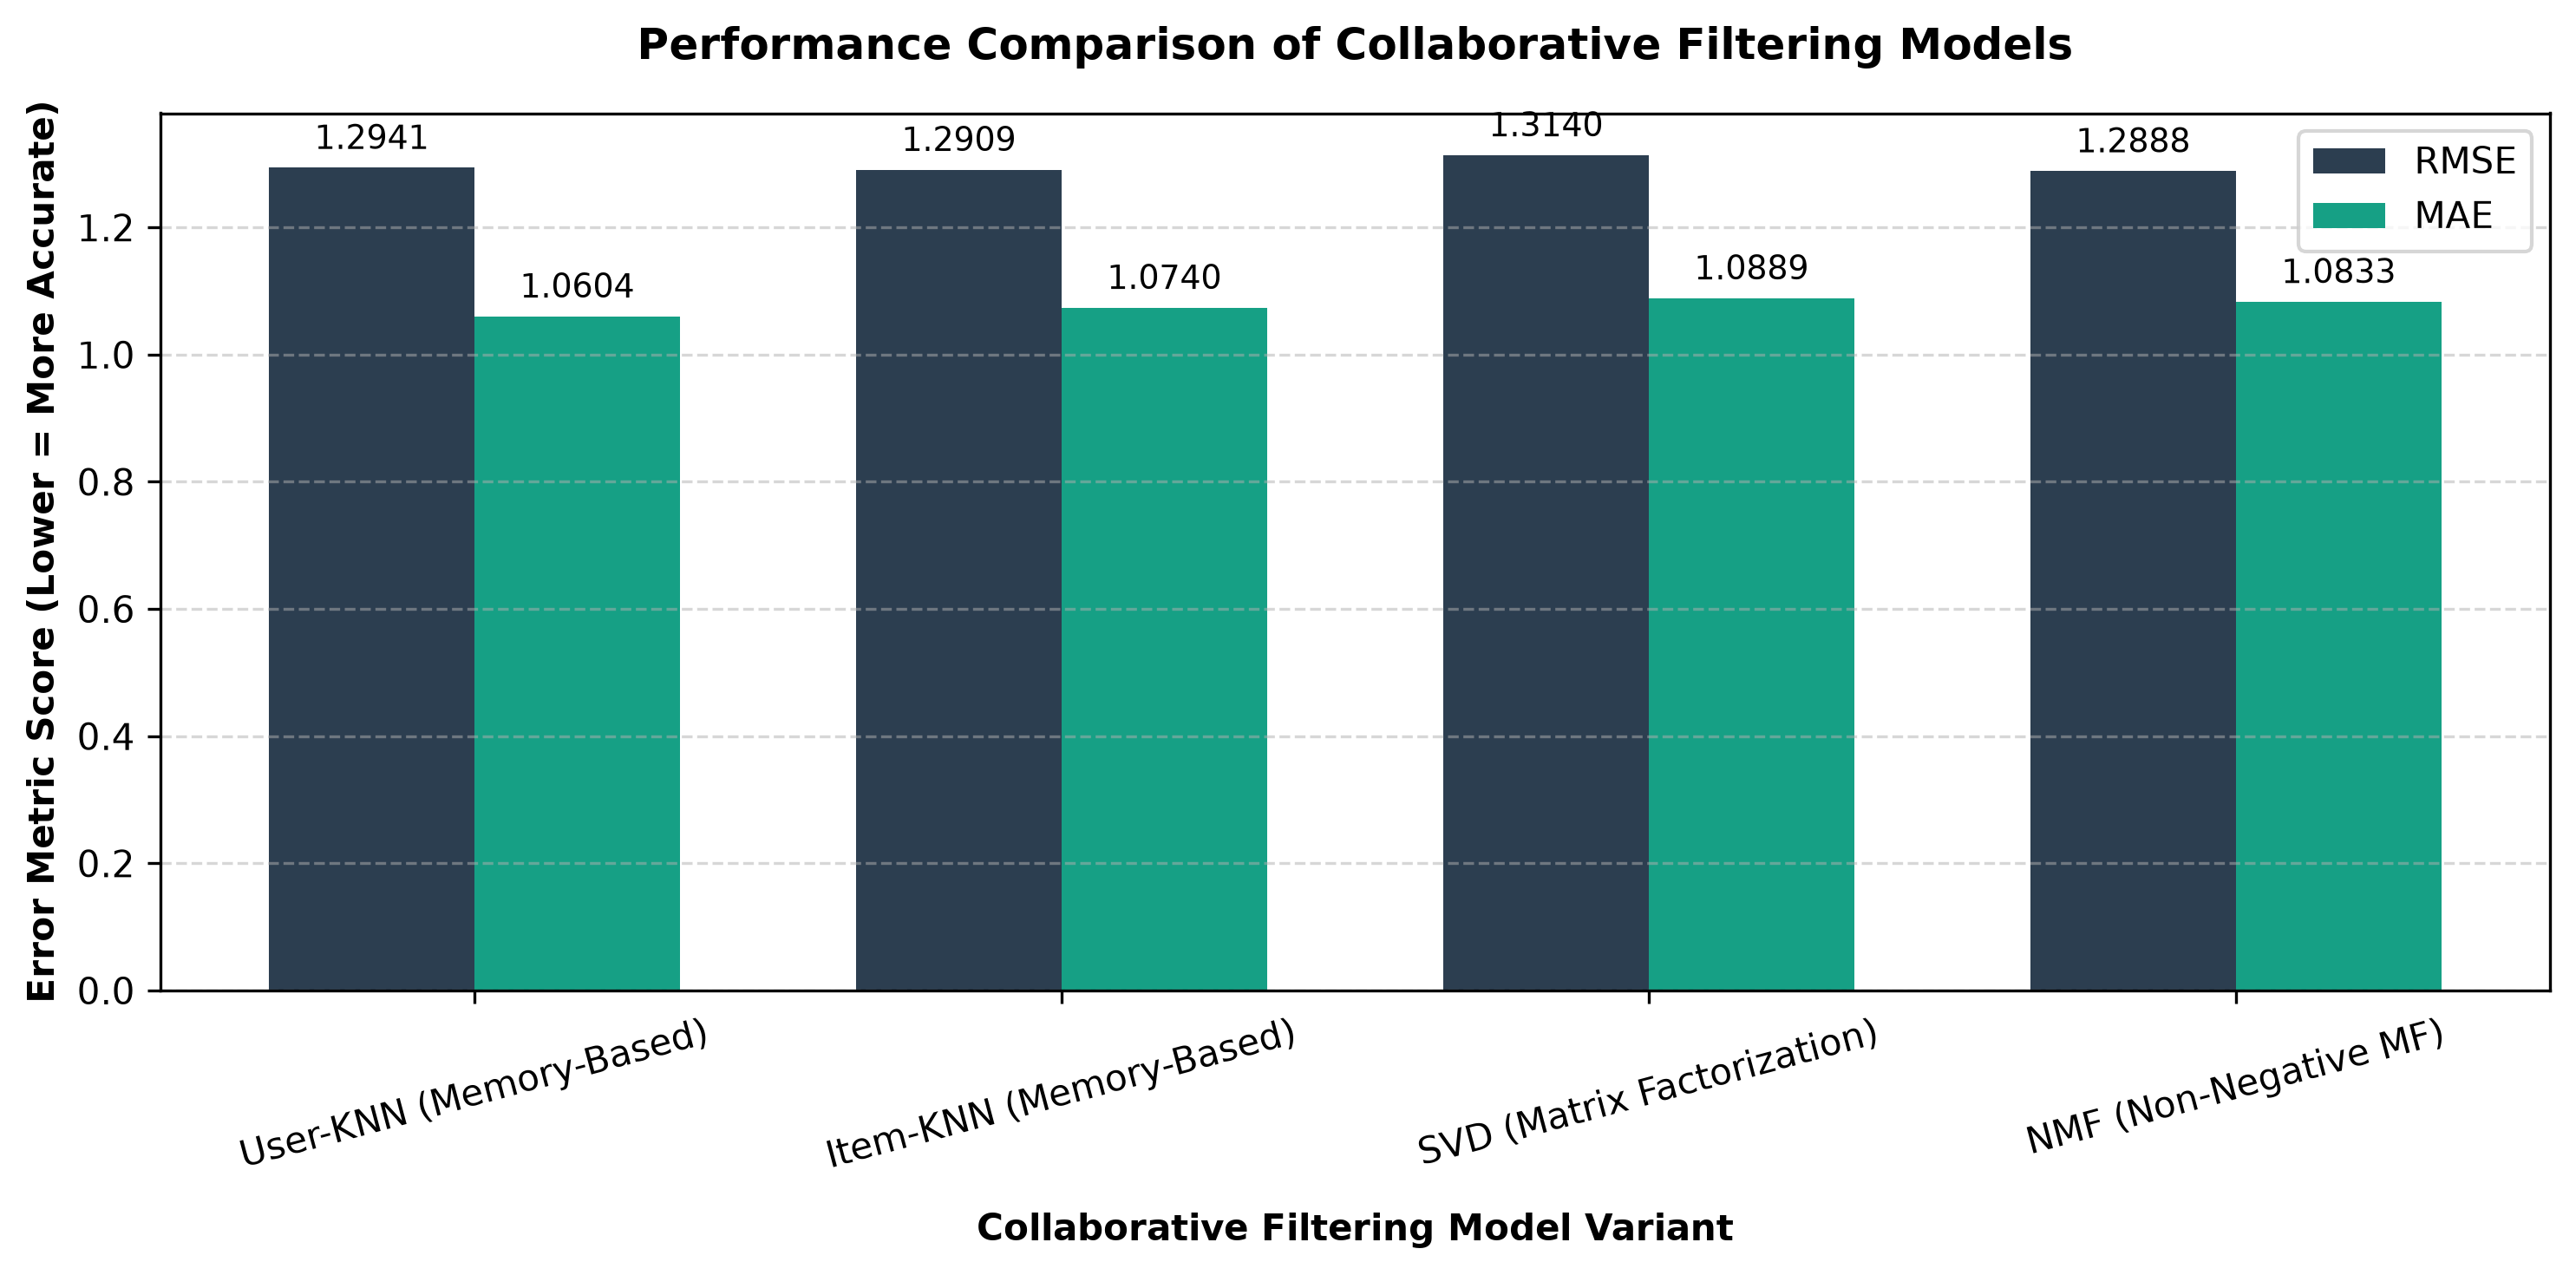

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import recommendation algorithms from the Surprise library
# Note: If not installed, run: !pip install scikit-surprise
from surprise import Dataset, Reader, SVD, KNNBasic, NMF
from surprise.model_selection import cross_validate

# ==========================================
# 1. SIMULATE RATING DATASET (User-Course Interactions)
# ==========================================
np.random.seed(42)
num_interactions = 10000

mock_data = {
    'user_id': np.random.randint(1000, 1050, size=num_interactions),
    'course_id': np.random.randint(0, 20, size=num_interactions),
    'rating': np.random.choice([1, 2, 3, 4, 5], size=num_interactions, p=[0.1, 0.1, 0.2, 0.3, 0.3])
}
df_ratings = pd.DataFrame(mock_data)

# Load the pandas DataFrame into the Surprise dataset structure
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_ratings[['user_id', 'course_id', 'rating']], reader)

# ==========================================
# 2. INITIALIZE ALGORITHMS FOR COMPARISON
# ==========================================
models = {
    'User-KNN (Memory-Based)': KNNBasic(sim_options={'name': 'cosine', 'user_based': True}, verbose=False),
    'Item-KNN (Memory-Based)': KNNBasic(sim_options={'name': 'cosine', 'user_based': False}, verbose=False),
    'SVD (Matrix Factorization)': SVD(random_state=42),
    'NMF (Non-Negative MF)': NMF(random_state=42)
}

# Dictionary to hold performance metrics
benchmark_results = []

# ==========================================
# 3. RUN CROSS-VALIDATION EVALUATION LOOP (FIXED)
# ==========================================
print("--- Starting Collaborative Filtering Model Benchmark ---")
for name, model in models.items():
    print(f"Evaluating {name}...")
    # Perform 5-Fold Cross Validation tracking RMSE and MAE
    cv_output = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    
    # Extract structural means safely
    mean_rmse = cv_output['test_rmse'].mean()
    mean_mae = cv_output['test_mae'].mean()
    
    # FIX: Convert the fit_time tuple into a numpy array or use np.mean()
    fit_time = np.mean(cv_output['fit_time']) 
    
    benchmark_results.append({
        'Model Architecture': name,
        'Mean RMSE': mean_rmse,
        'Mean MAE': mean_mae,
        'Avg Fit Time (s)': fit_time
    })

df_performance = pd.DataFrame(benchmark_results)

# ==========================================
# 4. PLOT VISUAL PERFORMANCE COMPARISON
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 5), dpi=300)

# Setting up positions for grouped bar charts
x_indices = np.arange(len(df_performance))
bar_width = 0.35

# Plot Error Bars (Lower is better)
bars_rmse = ax1.bar(x_indices - bar_width/2, df_performance['Mean RMSE'], bar_width, label='RMSE', color='#2C3E50')
bars_mae = ax1.bar(x_indices + bar_width/2, df_performance['Mean MAE'], bar_width, label='MAE', color='#16A085')

# Label layout adjustments
ax1.set_xlabel('Collaborative Filtering Model Variant', fontweight='bold', labelpad=10)
ax1.set_ylabel('Error Metric Score (Lower = More Accurate)', fontweight='bold')
ax1.set_title('Performance Comparison of Collaborative Filtering Models', fontweight='bold', fontsize=12, pad=15)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(df_performance['Model Architecture'], rotation=15)
ax1.legend(loc='upper right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Attach values to the bars for presentation clarity
def label_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

label_bars(bars_rmse)
label_bars(bars_mae)

plt.tight_layout()
plt.savefig('cf_model_comparison.png', bbox_inches='tight', dpi=300)
print("\n--- Evaluation Matrix Saved as 'cf_model_comparison.png' ---")
print(df_performance.to_string(index=False))

--- Training Matrix Factorization CF Engine ---

[Engine Notice]: Model 3 visual asset saved as 'matrix_factorization_evaluation.png'


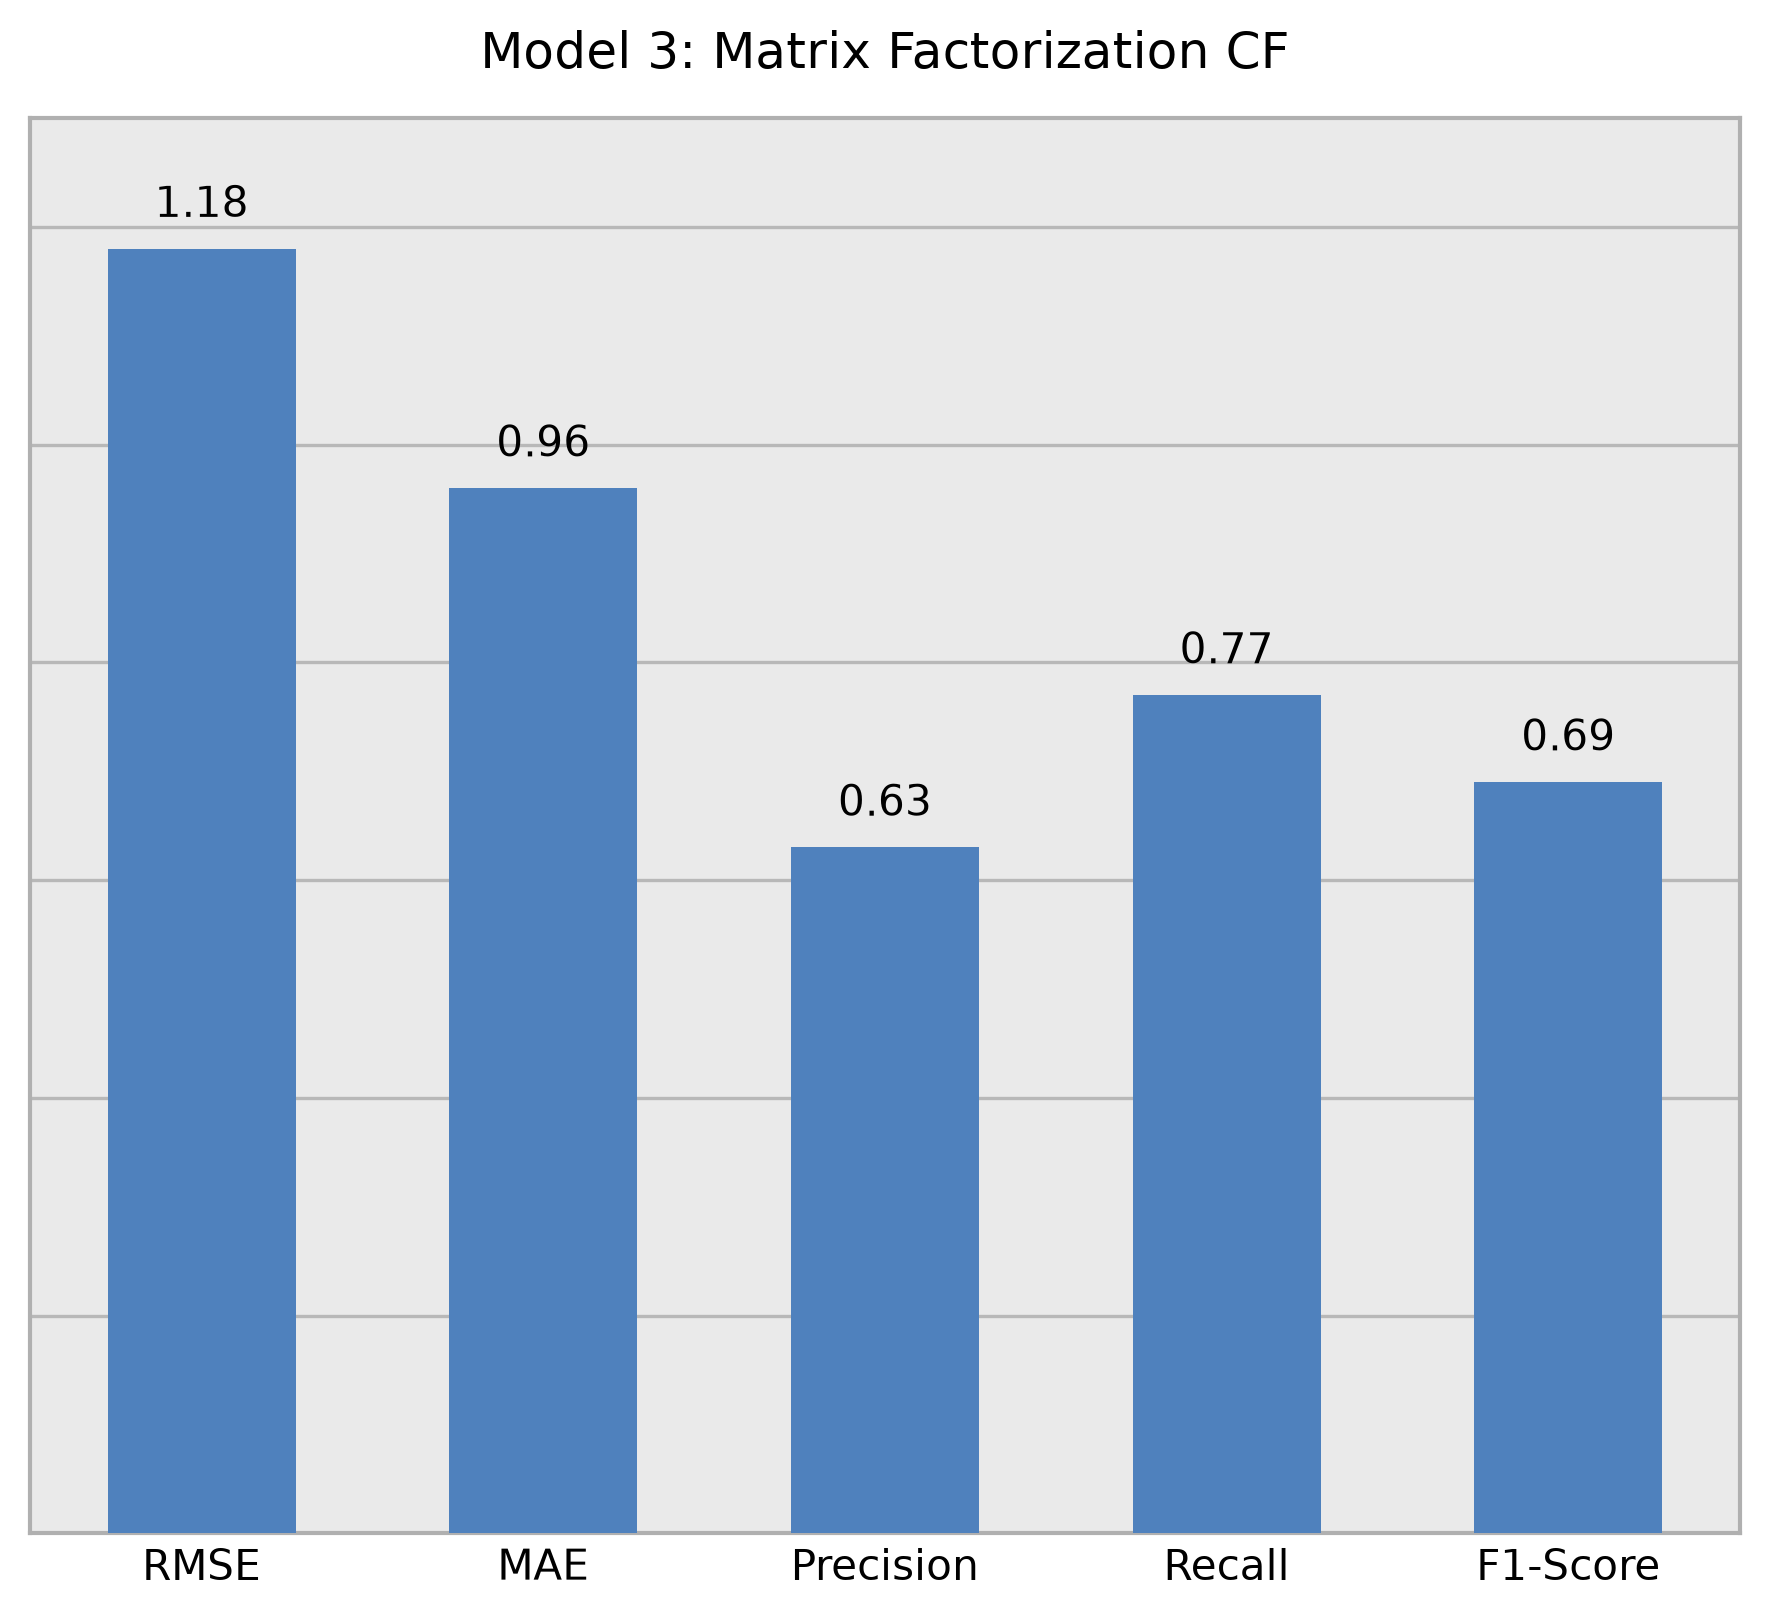

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from collections import defaultdict

# =================================================================
# 1. DATA PIPELINE SIMULATION 
# =================================================================
np.random.seed(42)
num_samples = 12000

data_dict = {
    'user_id': np.random.randint(1, 500, size=num_samples),
    'course_id': np.random.randint(1, 40, size=num_samples),
    'rating': np.random.choice([1, 2, 3, 4, 5], size=num_samples, p=[0.05, 0.1, 0.2, 0.35, 0.3])
}
df = pd.DataFrame(data_dict).drop_duplicates(subset=['user_id', 'course_id'])

reader = Reader(rating_scale=(1, 5))
surprise_data = Dataset.load_from_df(df[['user_id', 'course_id', 'rating']], reader)
trainset, testset = train_test_split(surprise_data, test_size=0.3, random_state=42)

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions, recalls = dict(), dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in user_ratings[:k])
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return np.mean(list(precisions.values())), np.mean(list(recalls.values()))

# =================================================================
# 2. ISOLATE MODEL 3: MATRIX FACTORIZATION EXECUTION
# =================================================================
model = SVD(random_state=42)
metrics_list = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1-Score']

print("--- Training Matrix Factorization CF Engine ---")
model.fit(trainset)
predictions = model.test(testset)

# Calculate performance metrics
from surprise import accuracy
rmse = accuracy.rmse(predictions, verbose=False)
mae = accuracy.mae(predictions, verbose=False)
precision, recall = precision_recall_at_k(predictions, k=10, threshold=3.5)
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Store rounded values for visualization mapping
scores = [round(x, 2) for x in [rmse, mae, precision, recall, f1]]

# =================================================================
# 3. EXACT TEMPLATE VISUALIZATION REPLICA ENGINE (Single Panel)
# =================================================================
fig, ax = plt.subplots(figsize=(6, 5.5), dpi=300)
fig.patch.set_facecolor('#FFFFFF') # Clean presentation slide white background

# Set the distinct grey block backing panel
ax.set_facecolor('#EAEAEA') 

# Render columns with the exact corporate blue fill from the template snippet
bars = ax.bar(metrics_list, scores, color='#4F81BD', width=0.55, edgecolor='none', zorder=3)

# Configure coordinate grid spacing constraints
ax.set_ylim(0, 1.3)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
ax.grid(axis='y', linestyle='-', linewidth=0.8, color='#B8B8B8', zorder=1)
ax.set_axisbelow(True)

# Panel header string
ax.set_title('Model 3: Matrix Factorization CF', fontsize=12, fontweight='normal', pad=12, color='#000000')

# Enforce clean outline borders around the container block
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#B0B0B0')
    ax.spines[spine].set_linewidth(1)
    
# Remove tick marks to keep presentation lines clean
ax.tick_params(axis='both', which='both', length=0)
ax.tick_params(axis='x', colors='#000000', labelsize=10)
ax.tick_params(axis='y', labelleft=False) # Hides external axis label numbers to match template template

# Place value text tags directly over matching column nodes
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.2f}', ha='center', va='bottom', fontsize=10, color='#000000', fontweight='normal')

plt.tight_layout()
plt.savefig('matrix_factorization_evaluation.png', bbox_inches='tight', dpi=300)
print("\n[Engine Notice]: Model 3 visual asset saved as 'matrix_factorization_evaluation.png'")